In [165]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Phase 1
### 1) load the datasets sample superstore
### 2) know no. of rows and cols
### 3) Know Data types
### 4) know if there is missing value

In [166]:
pd.set_option('display.max_columns',None)

In [167]:
df = pd.read_csv(r'Datasets/SampleSuperstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [169]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

# Phase 2
### 1) Convert Order Date and Ship Date Format to datetime64[s] format
### 2) add column delivery time
### 3) check is there negative column in sensitive column like (sales,discount).

In [170]:
df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')

In [171]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'],errors='coerce')

In [172]:
df.isnull().sum()

Row ID              0
Order ID            0
Order Date       5952
Ship Date        6096
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
dtype: int64

In [173]:
df['Delivery Time'] = df['Ship Date'] - df['Order Date']

In [174]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Time
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3 days
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3 days
2,3,CA-2016-138688,2016-06-12,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,NaT
3,4,US-2015-108966,2015-10-11,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,NaT
4,5,US-2015-108966,2015-10-11,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,NaT


In [175]:
df['Profit Margin (%)'] = (df['Profit']/df['Sales'])*100

In [176]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Time,Profit Margin (%)
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3 days,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3 days,30.00
2,3,CA-2016-138688,2016-06-12,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,NaT,47.00
3,4,US-2015-108966,2015-10-11,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,NaT,-40.00
4,5,US-2015-108966,2015-10-11,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,NaT,11.25


In [177]:
if (df['Postal Code'] < 0).any():
    print(f"Yes")
else:
    print("No")

No


In [178]:
if (df['Sales'] < 0).any():
    print(f"Yes")
else:
    print("No")

No


In [179]:
if (df['Quantity'] < 0).any():
    print(f"Yes")
else:
    print("No")

No


In [180]:
if (df['Discount'] < 0).any():
    print(f"Yes")
else:
    print("No")

No


In [181]:
df.duplicated().sum()

np.int64(0)

# Phase 3 (Visualization)

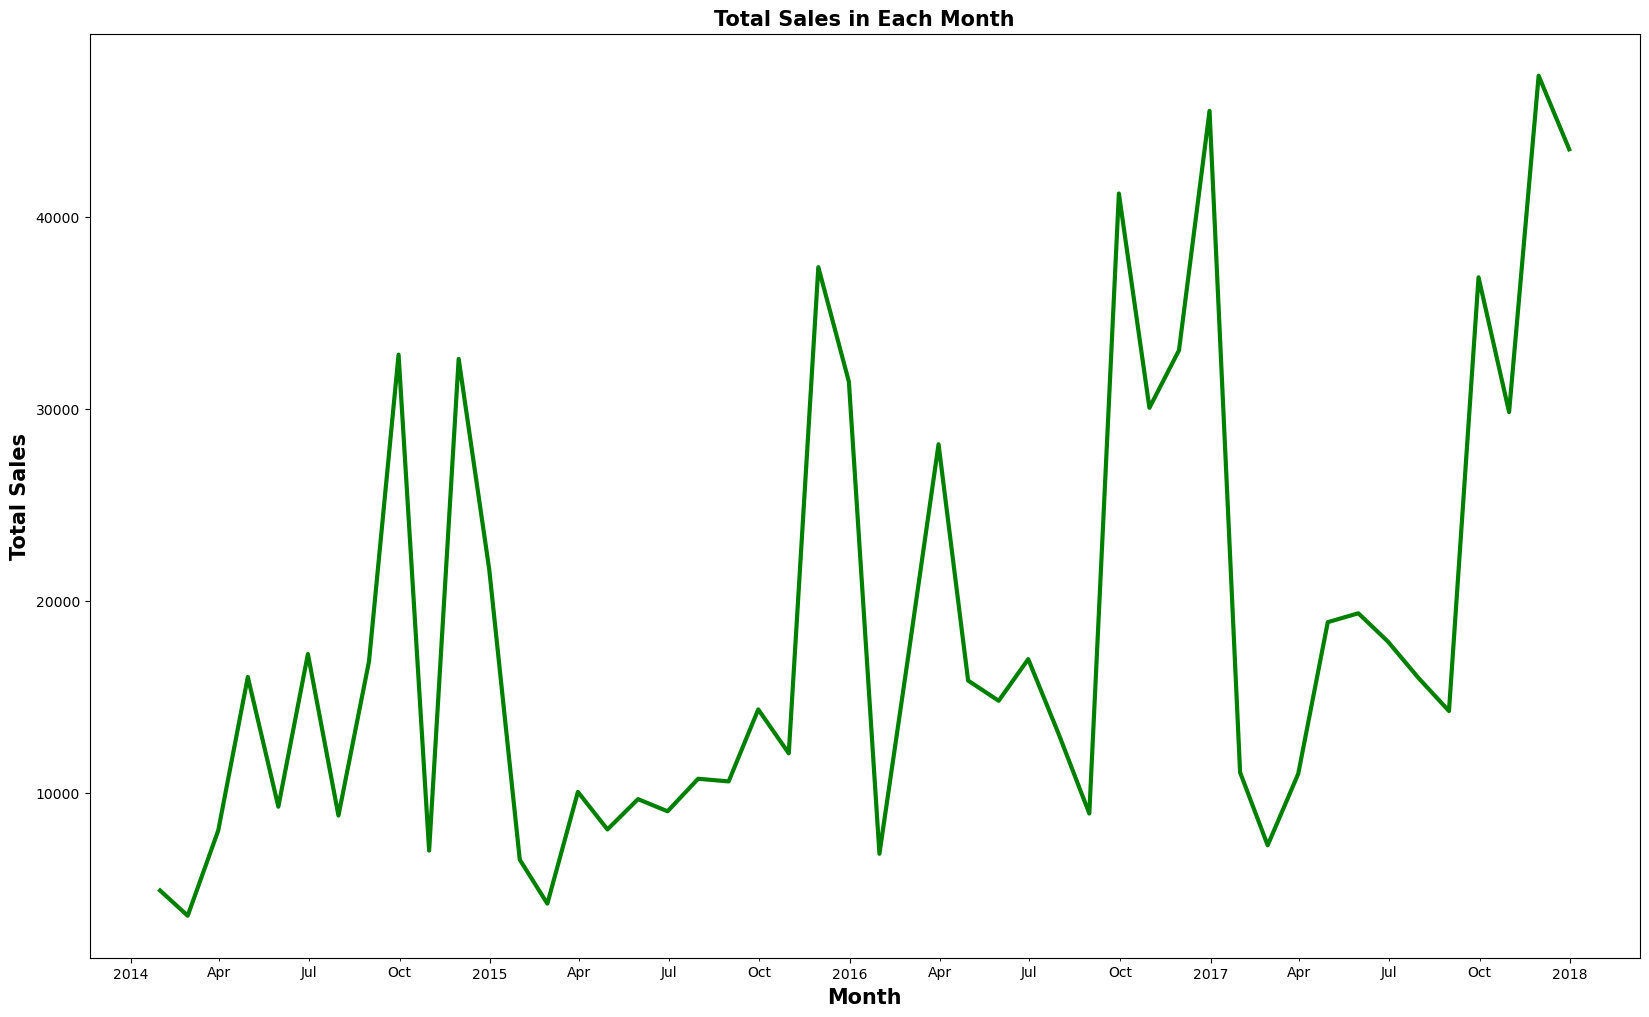

In [182]:
import matplotlib.dates as mdates
monthly_sales = df.set_index('Order Date',drop=False).resample('ME')['Sales'].sum()
fig, ax = plt.subplots(figsize=(20,12))
bar_cont = ax.plot(monthly_sales.index,monthly_sales.values,linewidth=3,c='green')
ax.set_title('Total Sales in Each Month',fontsize=15,fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Month',fontsize=15,fontweight='bold')
ax.set_ylabel('Total Sales',fontsize=15,fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
plt.show()

# My Analysis on above trend chart
### Between Jan to April the is Down but gradually growing and from 2014 overall sales is growing that means company is growing.

In [183]:
category_wise_profit = df.groupby('Category')['Profit'].sum()
category_wise_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

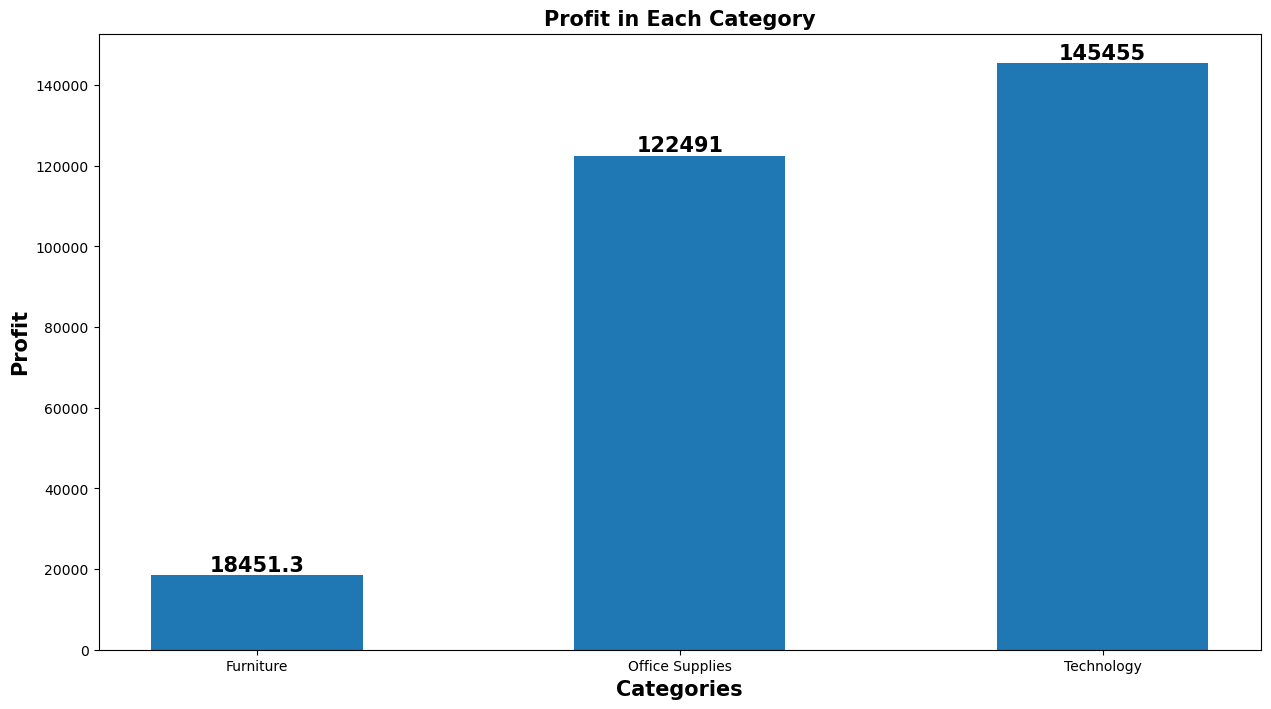

In [184]:
fig, ax = plt.subplots(figsize=(15,8))
bar_cont = ax.bar(category_wise_profit.index,category_wise_profit.values,width=0.5)
ax.bar_label(bar_cont,fontsize=15,fontweight='bold')
ax.set_title('Profit in Each Category',fontsize=15,fontweight='bold')
ax.set_xlabel('Categories',fontsize=15,fontweight='bold')
ax.set_ylabel('Profit',fontsize=15,fontweight='bold')
plt.show()

# Analysis on Bar Graph Above
### Furniture has Very Low Sales and whereas Technology has More Sales . So this Tell us the market trend from 2014 is towards technology is very high

In [185]:
df['Discount'] = df['Discount']*100

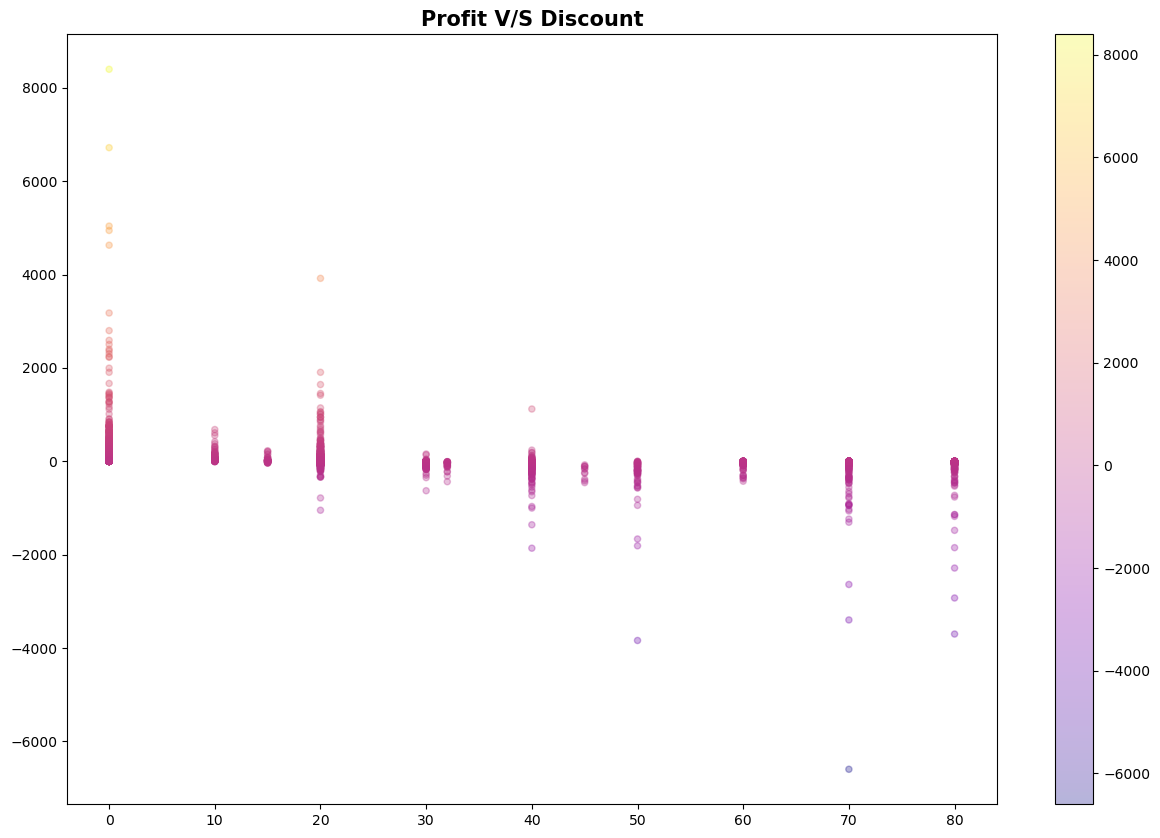

In [189]:
fig, ax  = plt.subplots(figsize=(15,10))
sc = ax.scatter(df['Discount'],df['Profit'],c=df['Profit'],s=20,cmap='plasma',alpha=0.3)
cm = fig.colorbar(sc,ax=ax)
ax.set_title('Profit V/S Discount',fontsize=15,fontweight='bold')
plt.show()

# Scatter Plot Analysis
### Above We acn see haS discount increase profit become less or negative but at 0% discount profit is high or non negative.